## Tarea 5

### Sección 3

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

Para identificar el tipo de tumor que se corresponde con el valor `0` y `1` de la columna `target` se puede hacer lo siguiente:
```python
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
target_labels = cancer.target[[10, 50, 85]]
print("Numerical labels:", target_labels)
print("Class names:", cancer.target_names[target_labels])
```

Lo cual da el siguiente resultado:
```python
Numerical labels: [0 1 0]
Class names: ['malignant' 'benign' 'malignant']
```

Indicando así que:
* target = 0 --> Maligno
* target = 1 --> Benigno

**Nota importante**:

En la presente entrega se considerará que el valor `0` en la columna `target` se corresponde con un tumor benigno, y que el valor `1` se corresponde con un tumor maligno (contrario a como está construido el dataset). Esto lo hacemos así porque queremos hacer la evaluación de detección de tumores malignos en lugar de benignos.

In [2]:
cancer = load_breast_cancer()
df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target # 0 = Benigno, 1 = Maligno
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

#### Sección 3.1

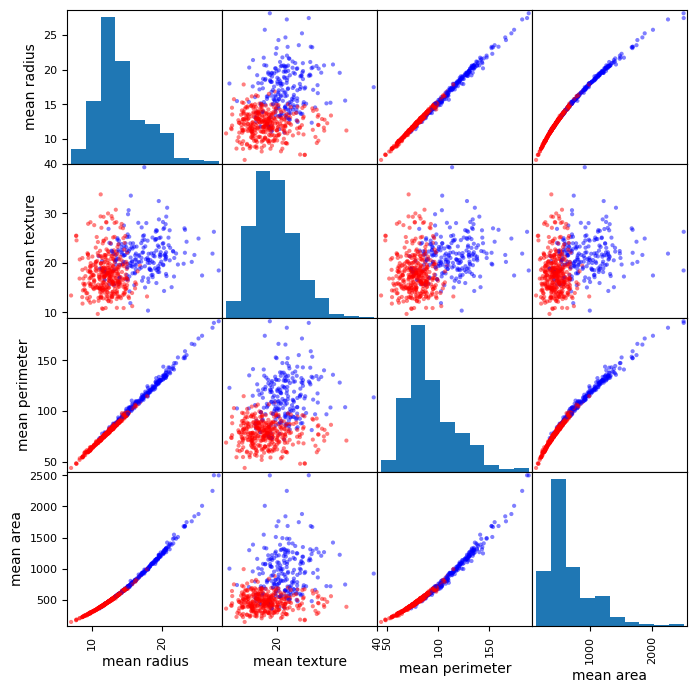

In [3]:
# from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
pd.plotting.scatter_matrix(df.iloc[:, :4], c=df['target'], cmap='bwr', figsize=(8,8))
plt.show()

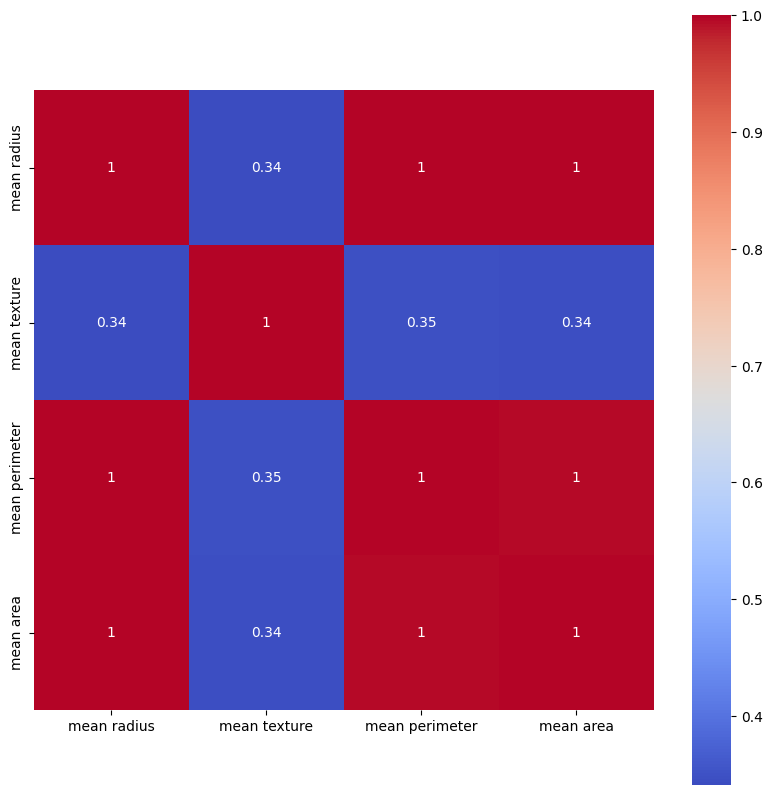

In [4]:
import seaborn as sns
plt.figure(figsize=(10, 10))
sns.heatmap(df.iloc[:, 0:4].corr(method='spearman'), annot=True, square=True, cmap='coolwarm')
plt.show()

#### Sección 3.2

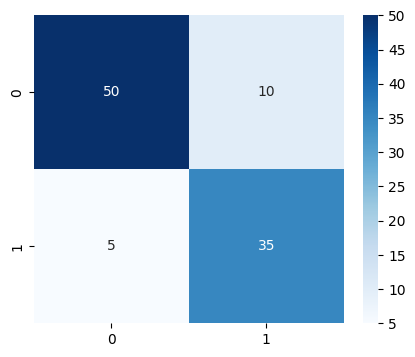

In [5]:
cm = [[50, 10], [5, 35]]
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

#### Sección 3.4

```python
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(df['target'], df['prediction'])
precision = precision_score(df['target'], df['prediction'])
recall = recall_score(df['target'], df['prediction'])
f1 = f1_score(df['target'], df['prediction'])
```

#### Sección 3.4

##### 3.4.1
Seleccionar __tres__ variables del conjunto con diferente correlación con el diagnóstico: una de alta correlación, una de correlación media y una de baja correlación. Para ello calcula la matriz de correlación y ordena los valores en orden descendente. Puedes usar `df.corr()[['target']]` para obtener la correlación de todas las variables con el diagnóstico (target).

En `df_correlacion` guardamos el DataFrame de la correlación de todas las variables con `target`. Después de ordenarlas de forma descendente consideramos todas las filas excepto la primera `[1:]`, pues la primera corresponde a la correlación de _target_ con _target_.

Nótese que se ordenan los valores en valor absoluto.

In [6]:
df_correlacion = df.corr()[['target']].sort_values(by='target', key=lambda x: abs(x), ascending=False)[1:]

# Variable con alta correlación
alta_corr = df_correlacion.iloc[0]

# Variable con media correlación (tomamos la décima variable solo por tomar alguna variable entre la alta y baja correlación)
media_corr = df_correlacion.iloc[10]

# Variable con baja correlación
baja_corr = df_correlacion.iloc[-1]

print(f'''
Variable con alta correlación: {alta_corr.name}
Variable con media correlación: {media_corr.name}
Variable con baja correlación: {baja_corr.name}
''')


Variable con alta correlación: worst concave points
Variable con media correlación: mean compactness
Variable con baja correlación: symmetry error



##### 3.4.2
Estudia las tres variables, puedes usar `df['VARIABLE'].describe()` para analizar su distribución y valores estadísticos.

Sin considerar distinción en el target

In [7]:
df[[alta_corr.name, media_corr.name, baja_corr.name]].describe()

,worst concave points,mean compactness,symmetry error
count,569.000000,569.000000,569.000000
mean,0.114606,0.104341,0.020542
std,0.065732,0.052813,0.008266
min,0.000000,0.019380,0.007882
25%,0.064930,0.064920,0.015160
50%,0.099930,0.092630,0.018730
75%,0.161400,0.130400,0.023480
max,0.291000,0.345400,0.078950


Considerando distinción en el target

In [8]:
df.groupby("target")[[alta_corr.name]].describe()

worst concave points                                                 \
                      count      mean       std      min      25%      50%   
target                                                                       
0                     212.0  0.182237  0.046308  0.02899  0.15275  0.18200   
1                     357.0  0.074444  0.035797  0.00000  0.05104  0.07431   

                         
             75%    max  
target                   
0       0.210675  0.291  
1       0.097490  0.175

In [9]:
df.groupby("target")[[media_corr.name]].describe()

mean compactness                                                 \
                  count      mean       std      min      25%      50%   
target                                                                   
0                 212.0  0.145188  0.053987  0.04605  0.10960  0.13235   
1                 357.0  0.080085  0.033750  0.01938  0.05562  0.07529   

                         
            75%     max  
target                   
0       0.17240  0.3454  
1       0.09755  0.2239

In [10]:
df.groupby("target")[[baja_corr.name]].describe()

symmetry error                                                   \
                count      mean       std       min       25%      50%   
target                                                                   
0               212.0  0.020472  0.010065  0.007882  0.014615  0.01770   
1               357.0  0.020584  0.006999  0.009539  0.015600  0.01909   

                           
             75%      max  
target                     
0       0.022132  0.07895  
1       0.024060  0.06146

##### 3.4.3

Dibuja las variables para tumores malignos y benignos, y usa la estimación de densidad de kernel (KDE) para visualizar su distribución.

Recordemos que: 
* target = 0 es benigno
* target = 1 es maligno

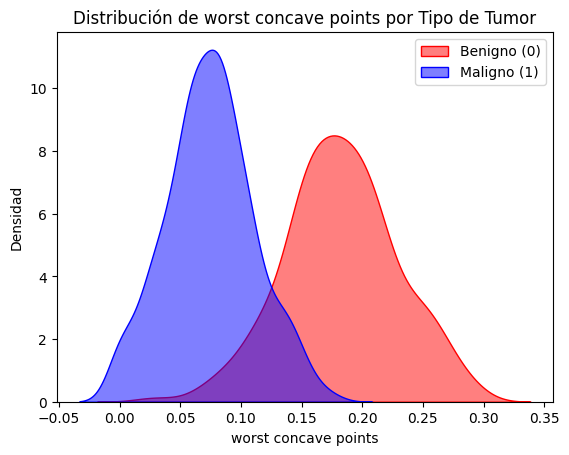

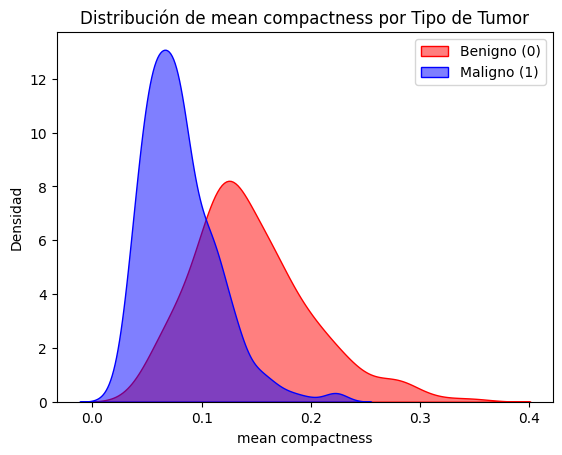

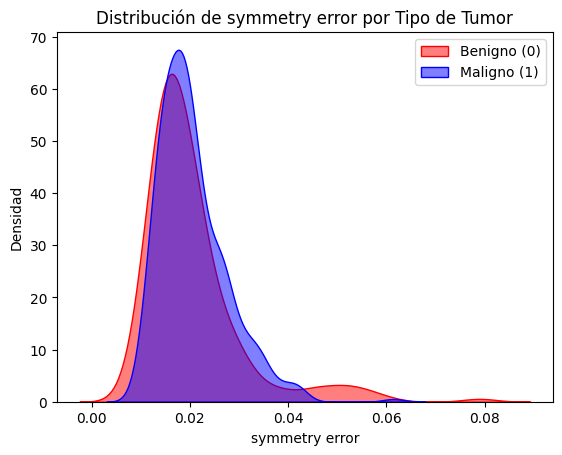

In [44]:
for name in [alta_corr.name, media_corr.name, baja_corr.name]:

    # plt.figure(figsize=(8, 5))
    sns.kdeplot(df[df['target'] == 0][name], label="Benigno (0)", fill=True, color="red", alpha=0.5)
    sns.kdeplot(df[df['target'] == 1][name], label="Maligno (1)", fill=True, color="blue", alpha=0.5)
    plt.xlabel(name)
    plt.ylabel("Densidad")
    plt.title("Distribución de " + name + " por Tipo de Tumor")
    plt.legend()
    plt.show()

##### 3.4.4

El siguiente paso es evaluar qué tan bien predicen si un tumor es Maligno (M) o Benigno (B). Para hacerlo de manera sencilla, podemos comparar esta variable con el diagnóstico real (target) y calcular la matriz de con fusión y las metricas.

##### 3.4.5

Escoge "a ojo" un valor de umbral para cada variable que te ayudará a clasificar los tumores como malignos (M = 1) o benignos (B = 0).

##### 3.4.6

Ahora asigna etiquetas de clasificación o predicción, esto significa que definas un `df['prediction']` tal que: si el valor de variable es menor o igual al umbral, predice M (Maligno). Si el valor de variable es mayor al umbral, predice B (Benigno).

Para definir el valor umbral para las tres variables con las que estamos trabajando tomaremos aquel valor que "a ojo" divida en dos a las distribuciones de cada tipo de tumor.

* Para _worst concave points_: 0.12
* Para _mean compactness_: 0.1
* Para _symmetry error_: 0.02

Columnas generadas:
* *prediccion_alta_corr*: Predicción obtenida con el umbral de _worst concave points_.
* *prediccion_media_corr*: Predicción obtenida con el umbral de _mean compactness_.
* *prediccion_baja_corr*: Predicción obtenida con el umbral de _symmetry error_.


> `DataFrame.astype(int)` para convertir booleano a entero:
> * `int(False) -> 0`
> * `int(True) -> 1`  

In [12]:
alta_corr_umbral = 0.12
media_corr_umbral = 0.1
baja_corr_umbral = 0.02

df['prediccion_alta_corr'] = (df[alta_corr.name] <= alta_corr_umbral).astype(int)  # 0 = Benigno, 1 = Maligno
df['prediccion_media_corr'] = (df[media_corr.name] <= media_corr_umbral).astype(int)
df['prediccion_baja_corr'] = (df[baja_corr.name] <= baja_corr_umbral).astype(int)

##### 3.4.7 Falta responder esta pregunta

Imprime las primeras 30 filas con los valores reales del diagnóstico y las predicciones generadas. 
¿Por qué hay casos con target = 0 (Benigno) que tienen prediction = 1 (Maligno)?

La razón por la cual la predicción hecha no coincide con el valor del target es 

solo nos estamos fijando en una variable para clasificar. esta variable puede no ser suficiente para hacer una correcta clasificación.  el umbral elegido fue elegido a ojo sin ningún criterio que confirme que dicho valor indique una correcta clasificacion.

In [13]:
df[[alta_corr.name, media_corr.name, baja_corr.name, 'prediccion_alta_corr', 'prediccion_media_corr', 'prediccion_baja_corr', 'target']].head(30)

,worst concave points,mean compactness,symmetry error,prediccion_alta_corr,prediccion_media_corr,prediccion_baja_corr,target
0,0.26540,0.27760,0.03003,0,0,0,0
1,0.18600,0.07864,0.01389,0,1,1,0
2,0.24300,0.15990,0.02250,0,0,0,0
3,0.25750,0.28390,0.05963,0,0,0,0
4,0.16250,0.13280,0.01756,0,0,1,0
5,0.17410,0.17000,0.02165,0,0,0,0
6,0.19320,0.10900,0.01369,0,0,1,0
7,0.15560,0.16450,0.01486,0,0,1,0
8,0.20600,0.19320,0.02143,0,0,0,0
9,0.22100,0.23960,0.01789,0,0,1,0


##### 3.4.8

Define FP: casos donde el target real es 0 (Benigno) pero la predicción es 1 (Maligno). 

Define FN: casos donde el target real es 1 (Maligno) pero la predicción es 0 (Benigno). 

Cuéntalos y encuentra cuantas predicciones fallaron.

Recordemos que tenemos un total de **569** datos.

In [14]:
# Para worst concave points
FP_alta_corr = df[(df['target'] == 0) & (df['prediccion_alta_corr'] == 1)]
FN_alta_corr = df[(df['target'] == 1) & (df['prediccion_alta_corr'] == 0)]
TN_alta_corr = df[(df['target'] == 0) & (df['prediccion_alta_corr'] == 0)]
TP_alta_corr = df[(df['target'] == 1) & (df['prediccion_alta_corr'] == 1)]
print("""
Para {0} hay: 
{1} predicciones FP
{2} predicciones FN
Son {3} predicciones que fallaron.
""".format(alta_corr.name, FP_alta_corr.shape[0], FN_alta_corr.shape[0], FP_alta_corr.shape[0] + FN_alta_corr.shape[0]))

# Para mean compactness
FP_media_corr = df[(df['target'] == 0) & (df['prediccion_media_corr'] == 1)]
FN_media_corr = df[(df['target'] == 1) & (df['prediccion_media_corr'] == 0)]
TN_media_corr = df[(df['target'] == 0) & (df['prediccion_media_corr'] == 0)]
TP_media_corr = df[(df['target'] == 1) & (df['prediccion_media_corr'] == 1)]
print("""
Para {0} hay: 
{1} predicciones FP
{2} predicciones FN
Son {3} predicciones que fallaron.  
""".format(media_corr.name, FP_media_corr.shape[0], FN_media_corr.shape[0], FP_media_corr.shape[0] + FN_media_corr.shape[0]))

# Para symmetry error
FP_baja_corr = df[(df['target'] == 0) & (df['prediccion_baja_corr'] == 1)]
FN_baja_corr = df[(df['target'] == 1) & (df['prediccion_baja_corr'] == 0)]
TN_baja_corr = df[(df['target'] == 0) & (df['prediccion_baja_corr'] == 0)]
TP_baja_corr = df[(df['target'] == 1) & (df['prediccion_baja_corr'] == 1)]
print("""
Para {0} hay: 
{1} predicciones FP
{2} predicciones FN
Son {3} predicciones que fallaron.  
""".format(baja_corr.name, FP_baja_corr.shape[0], FN_baja_corr.shape[0], FP_baja_corr.shape[0] + FN_baja_corr.shape[0]))


Para worst concave points hay: 
19 predicciones FP
40 predicciones FN
Son 59 predicciones que fallaron.


Para mean compactness hay: 
36 predicciones FP
86 predicciones FN
Son 122 predicciones que fallaron.  


Para symmetry error hay: 
135 predicciones FP
152 predicciones FN
Son 287 predicciones que fallaron.  



##### 3.4.9

Dibuja la matriz de confusión completa.

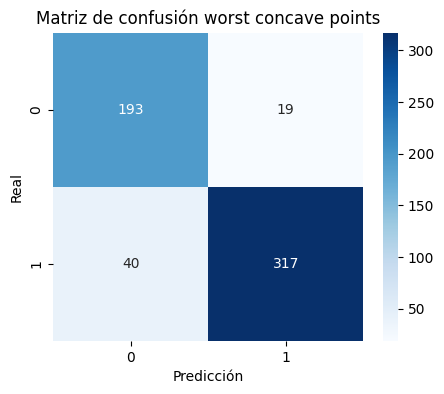

In [15]:
# Para worst concave points
mc_alta_corr = [[TN_alta_corr.shape[0], FP_alta_corr.shape[0]],
                [FN_alta_corr.shape[0], TP_alta_corr.shape[0]]]
plt.figure(figsize=(5,4))
sns.heatmap(mc_alta_corr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión '+alta_corr.name)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

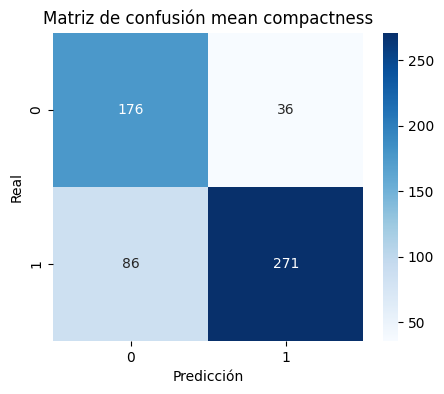

In [16]:
# Para mean compactness
mc_media_corr = [[TN_media_corr.shape[0], FP_media_corr.shape[0]],
                [FN_media_corr.shape[0], TP_media_corr.shape[0]]]
plt.figure(figsize=(5,4))
sns.heatmap(mc_media_corr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión '+media_corr.name)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

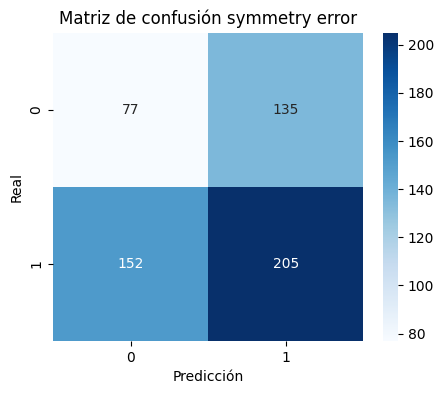

In [17]:
# Para symmetry error
mc_baja_corr = [[TN_baja_corr.shape[0], FP_baja_corr.shape[0]],
                [FN_baja_corr.shape[0], TP_baja_corr.shape[0]]]
plt.figure(figsize=(5,4))
sns.heatmap(mc_baja_corr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión '+baja_corr.name)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

##### 3.4.10 Falta responder pregunta

Evalua todas las 4 metricas que apenas vimos. 
¿Tu modelo es confiable?

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

predicciones = ['prediccion_alta_corr', 'prediccion_media_corr', 'prediccion_baja_corr']
variables = [alta_corr.name, media_corr.name, baja_corr.name]

labels = ['variable', 'accuracy', 'precision', 'recall', 'f1']
metricas = [[],[],[]]

for i, var in enumerate(zip(variables, predicciones)):
    metricas[i].append(var[0])
    metricas[i].append(accuracy_score(df['target'], df[var[1]]))
    metricas[i].append(precision_score(df['target'], df[var[1]]))
    metricas[i].append(recall_score(df['target'], df[var[1]]))
    metricas[i].append(f1_score(df['target'], df[var[1]]))
    
df_metricas = pd.DataFrame(metricas, columns=labels)

df_metricas
# df_metricas.to_dict()

,variable,accuracy,precision,recall,f1
0,worst concave points,0.896309,0.943452,0.887955,0.914863
1,mean compactness,0.785589,0.882736,0.759104,0.816265
2,symmetry error,0.495606,0.602941,0.574230,0.588235


In [43]:
# Importar librerías necesarias
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Cargar el dataset
data = load_breast_cancer()
X = data.data  # Características
y_true = data.target  # Variable objetivo

# Extraer la característica 'worst concave points' (índice 27 según load_breast_cancer().feature_names)
worst_concave_points = X[:, 27]

# Binarizar la característica usando la mediana como umbral
threshold = 0.12
y_pred = (worst_concave_points >= threshold).astype(int)  # Convertir en 0 o 1

# Calcular métricas de clasificación
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f'Accuracy: {accuracy:.6f}')
print(f'Precision: {precision:.6f}')
print(f'Recall: {recall:.6f}')
print(f'F1 Score: {f1:.6f}')


Accuracy: 0.103691
Precision: 0.171674
Recall: 0.112045
F1 Score: 0.135593


##### 3.4.11

Para probar diferentes valores de umbral, necesitamos graficar la "Precision Recall Curve" para ver el mejor punto de equilibrio:

```python
from sklearn.metrics import precision_recall_curve
true = df['target']
var = df['alguna variable']
precision, recall, thresholds = precision_recall_curve(true, var)
plt.plot(thresholds, precision[:-1], label="Precision", linestyle="--")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Umbral")
plt.ylabel("Valor")
plt.legend()
plt.show()
```


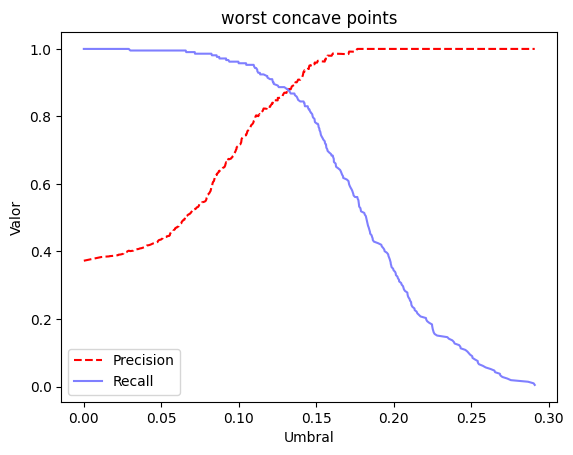

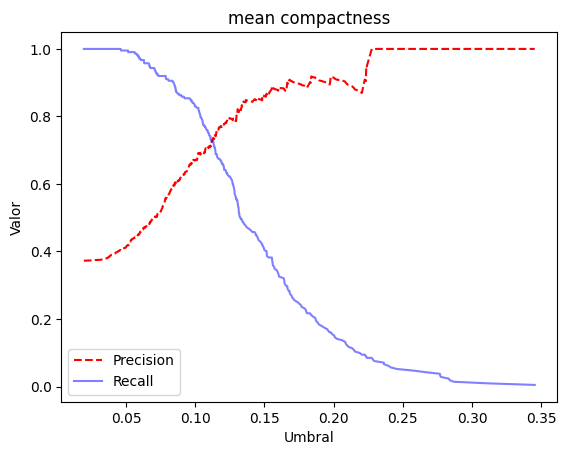

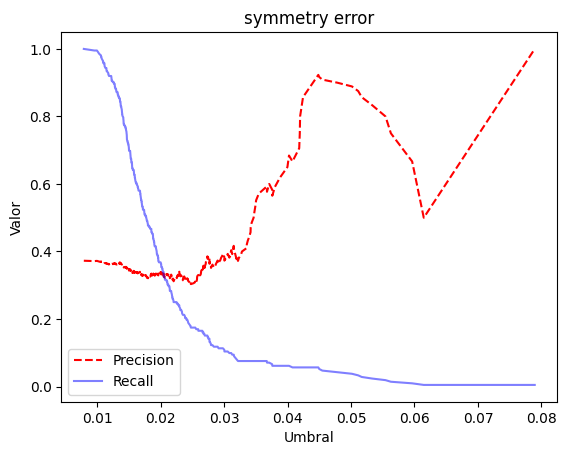

In [ ]:
from sklearn.metrics import precision_recall_curve
true = df['target'] # 1 = Benigno, 0 = Maligno
true_invertido = 1 - true   # Ahora 1 = Maligno, 0 = Benigno
for name in variables:
    var = df[name]
    precision, recall, thresholds = precision_recall_curve(true_invertido, var)
    plt.plot(thresholds, precision[:-1], label="Precision", linestyle="--", color='red')
    plt.plot(thresholds, recall[:-1], label="Recall", color='blue', alpha=0.5)
    plt.title(name)
    plt.xlabel("Umbral")
    plt.ylabel("Valor")
    plt.legend()
    plt.show()